**Title**: Job Monitoring etc...

**Date**:  TBD

**Description**:  
TBD

### **Requirements**:
1. Access to a Flywheel instance.
3. A Flywheel API key.
2. A Flywheel Project with ideally the dataset used in the [upload-data notebook](https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb).
2. Site Admin Permission?
3. Have some jobs running in your Flywheel Project

<div class="alert alert-block alert-warning" >
    <b>NOTE:</b> This notebook is using a test dataset provided by the <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">upload-data notebook</a>. If you have not uploaded this test dataset yet, we strongly recommend you do so now following steps in <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">here</a> before proceeding because this notebook is based on a specific project structure.
</div>

<div class="alert alert-block alert-danger" >
    <b>WARNING:</b> The metadata of the acquisitions in your test project will be updated and new files will be created after running the scripts below. 
</div>

# Install and Import Dependencies

In [ ]:
# Install specific packages required for this notebook
!pip install flywheel-sdk pandas

In [1]:
# Import packages
from getpass import getpass
import logging
import os
from pathlib import Path
import re
import time
import pprint
from dateutil.tz import tzutc


from IPython.display import display, Image
import flywheel
import pandas as pd
from tqdm import tqdm
from scipy import stats as st
import matplotlib.pyplot as plt
from scipy.stats import normaltest


In [2]:
# Instantiate a logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger('root')

# Flywheel API Key and Client

Get a API_KEY. More on this at in the Flywheel SDK doc [here](https://flywheel-io.gitlab.io/product/backend/sdk/branches/master/python/getting_started.html#api-key).

In [35]:
API_KEY = getpass('Enter API_KEY here: ')

Enter API_KEY here:  ····································


Instantiate the Flywheel API client

In [36]:
fw = flywheel.Client(API_KEY or os.environ.get('FW_KEY'))

Show Flywheel logging information

In [37]:
log.info('You are now logged in as %s to %s', fw.get_current_user()['email'], fw.get_config()['site']['api_url'])

2020-06-17 15:32:02,239 INFO You are now logged in as tanxx587@umn.edu to https://ss.ce.flywheel.io:443/api


***

# Initialize a few value

Define your test Project's Label and let's look for it on your Flywheel instance.

In [47]:
PROJECT_LABEL = input('Please enter your Project Label here: ')

Please enter your Project Label here:  anx_test


# Check Permission

***

- A follow up from the previous notebook - etc - explanation

we now want to monitor the jobs that were triggered in the batch-run gear notebook, and we gonna check the state and cancel a few just for sake of example

In [48]:
project = fw.projects.find_first(f'label={PROJECT_LABEL}')

In [49]:
mriqc_gear = fw.lookup('gears/mriqc')

In [50]:
def run_gear(gear, inputs, dest):
    """Submits a job with specified gear and inputs.
    
    Args:
        gear (flywheel.Gear): A Flywheel Gear.
        inputs (dict): Input dictionary for the gear.
        dest (flywheel.container): A Flywheel Container where the output will be stored.
        
    Returns:
        str: The id of the submitted job.
        
    """
    try:
        # Run the gear on the inputs provided, stored output in dest constainer and returns job ID
        gear_job_id = gear.run(inputs=inputs, destination=dest)
        log.debug('Submitted job %s', gear_job_id)
        return gear_job_id
    except flywheel.rest.ApiException:
        log.exception('An exception was raised when attempting to submit a job for %s',
                      file_obj.name)

In [51]:
# Initialize mriqc_job_list
mriqc_job_list = list()
# Iterate over project sessions
for session in project.sessions.iter():
    # Iterate over sessions acquisition
    for i, acq in enumerate(session.acquisitions.iter()):
        for file_obj in acq.files:
            # We only want DICOMs
            if file_obj.type == 'nifti':
                inputs = {'nifti':file_obj}
                dest = file_obj.parent
                job_id = run_gear(mriqc_gear, inputs, dest)
                mriqc_job_list.append(job_id)
            if i > 5:
                break

In [ ]:
job = fw.get_current_user_jobs()['jobs']

for i in job:
    print(i.gear_info['name'])



In [ ]:
for j in fw.jobs.find('origin.id=huiqiantan@flywheel.io'):
    print(j.gear_info['name'])

In [53]:
gear_name = 'mriqc'

In [ ]:
for j in fw.jobs.find(f'gear_info.name={gear_name}'):
    job = fw.get_job(j.id)
    print(job.gear_info['name'])


100%|██████████| 50/50 [00:04<00:00, 12.47it/s]


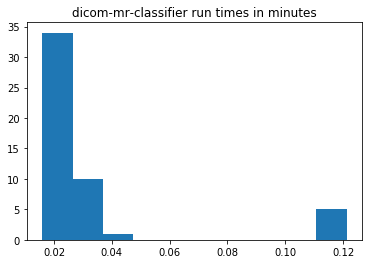

In [55]:
# GET RUN TIMES + PLOT

gear_name = 'dicom-mr-classifier'
created_post = '2020-06-15'
sample_size_max = 50
plot = True

run_times = list()

for j in tqdm(fw.jobs.find(f'gear_info.name={gear_name},state=complete,created>{created_post}', limit=sample_size_max)):
    job = fw.get_job(j.id)
    time_delta = job.transitions.complete - job.transitions.running
    run_times.append(time_delta.total_seconds()/60)

if plot:
    plt.hist(run_times)
    plt.title("{} run times in minutes".format(gear_name))
    plt.show()

In [ ]:
#JOb status
for job in mriqc_job_list:
    job_info = fw.get_job(job)
    log.info('Submitted Job Status: %s', job_info.state)

***

# Jobs I launched

With `get_current_user_jobs` method will return the jobs you launched without a site admin role.


In [ ]:
test = fw.get_current_user_jobs()
print(test)

In [10]:
jobs = fw.get_current_user_jobs()['jobs']

for i, job in enumerate(jobs):
    print(job.id)
    if i > 5:
        break
    

5eb2ea25bfda5101486aa0af
5eb2ea26bfda5101486aa0b0
5eb2ea26bfda5101486aa0b1
5eb2ea26bfda5101486aa0b2
5eb2ea26bfda5101486aa0b3
5ec581a9bfda5103816aa099
5ec58763bfda5103896aa07f


You can also use `get_job` method to retrun the jobs you launched but you will be a site admin to run this. 

In [ ]:
for j in fw.jobs.find('origin.id=huiqiantan@flywheel.io'):
    print(j.gear_info['name'])

In [11]:
all_jobs = fw.jobs.find('origin.id=huiqiantan@flywheel.io')

In [13]:
for i, job in enumerate(all_jobs):
    print(job.id)
    if i > 5:
        break

5eb2ea25bfda5101486aa0af
5eb2ea26bfda5101486aa0b0
5eb2ea26bfda5101486aa0b1
5eb2ea26bfda5101486aa0b2
5eb2ea26bfda5101486aa0b3
5ec581a9bfda5103816aa099
5ec58763bfda5103896aa07f


***

# Filter based on:
- gear name
- date/time
- state

In [14]:
GEAR_NAME = 'dicom-mr-classifier'

In [17]:
jobs = fw.jobs.find(f'gear_info.name={GEAR_NAME}')


In [21]:
for i, j in enumerate(jobs):
    print(j.state)
    if i > 5:
        break

failed
complete
complete
complete
complete
complete
complete


In [23]:
CREATED_POST = '2020-06-10'

In [ ]:
jobs = fw.jobs.find(f'gear_info.name={GEAR_NAME},created>{CREATED_POST}')


In [ ]:
for i, j in enumerate(jobs):
    print(j.origin)
    


In [65]:
jobs = fw.get_current_user_jobs()['jobs']

In [ ]:
for job in jobs:
    print(job.gear_info.name)

***

# Cancelling Job

In [60]:
jobs = fw.get_current_user_jobs()['jobs']


In [ ]:
for j in jobs:
    print(j.gear_info.name)
    print(j.state)
    if j.state == 'pending':
        j.update(state='cancelled')

***

# Restarting Job

Job only can be retry once. 

In [ ]:
for j in jobs:
    if j.state == 'pending' and j.gear_info['name']:
        fw.retry_job(j.id)
        

***

# Pulling statistics on jobs for a specific gear:
- states
- average run time
- Getting logs for failed job